Step 1: Import all the libraries we'll need

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

Step 2: Get the dataset into Colab

In [10]:
from google.colab import files
files.upload()  # choose your kaggle.json file when prompted

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO.csv


{'CAR DETAILS FROM CAR DEKHO.csv': b'name,year,selling_price,km_driven,fuel,seller_type,transmission,owner\r\nMaruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner\r\nMaruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner\r\nHyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner\r\nDatsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner\r\nHonda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner\r\nMaruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner\r\nHyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner\r\nTata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner\r\nHyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner\r\nMaruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner\r\nChevrolet Sail 1.2 Base,2015,260000,35000,Petrol,Individual,Manual,First Owner\r\n

Step 3: Load the dataset into pandas

In [11]:
data = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
print(f"Dataset Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Dataset Shape: (4340, 8)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


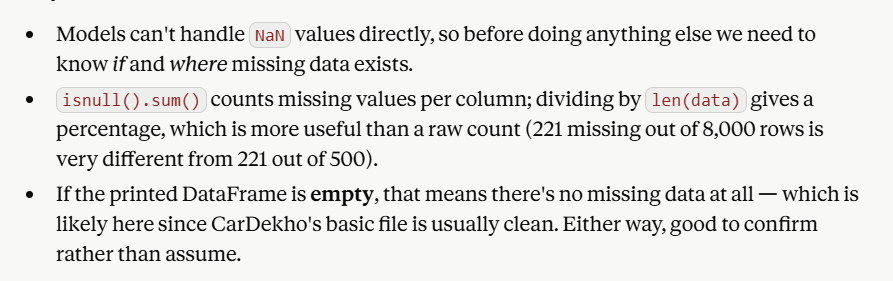

In [12]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


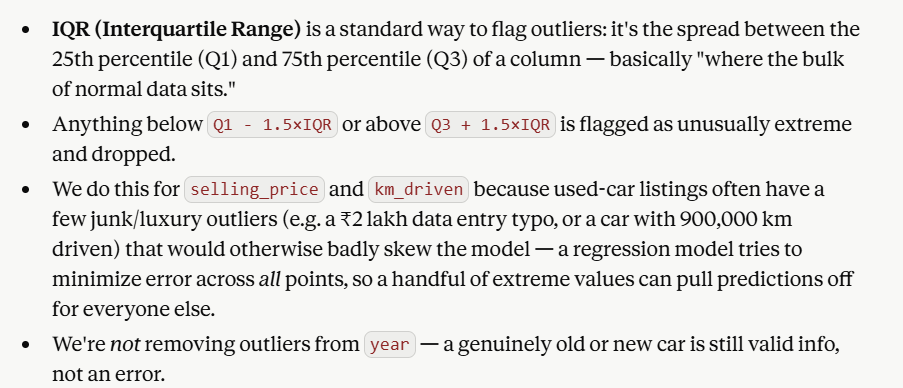

In [13]:
def remove_outliers_iqr(df, column, multiplier=1.5):
    """Remove outliers using the IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    before = len(df)
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    after = len(df)
    print(f"{column}: Removed {before - after} outliers ({((before-after)/before*100):.1f}%)")
    return df

outlier_cols = ['selling_price', 'km_driven']
for col in outlier_cols:
    data = remove_outliers_iqr(data, col)

selling_price: Removed 271 outliers (6.2%)
km_driven: Removed 107 outliers (2.6%)


Step 6: Feature engineering



In [14]:
 #Car age — easier for a model to use than raw year
data['car_age'] = 2024 - data['year']

# Extract brand from the car name (first word, with a few exceptions)
def extract_brand(name):
    name = str(name).strip()
    multi_word_brands = ['Land Rover', 'Alfa Romeo', 'Aston Martin']
    for brand in multi_word_brands:
        if name.lower().startswith(brand.lower()):
            return brand
    return name.split()[0]

data['brand'] = data['name'].apply(extract_brand)

# Log-transform the target to reduce skewness
data['log_selling_price'] = np.log1p(data['selling_price'])

# How hard the car has been driven, normalized by age
data['km_per_year'] = data['km_driven'] / (data['car_age'] + 1)

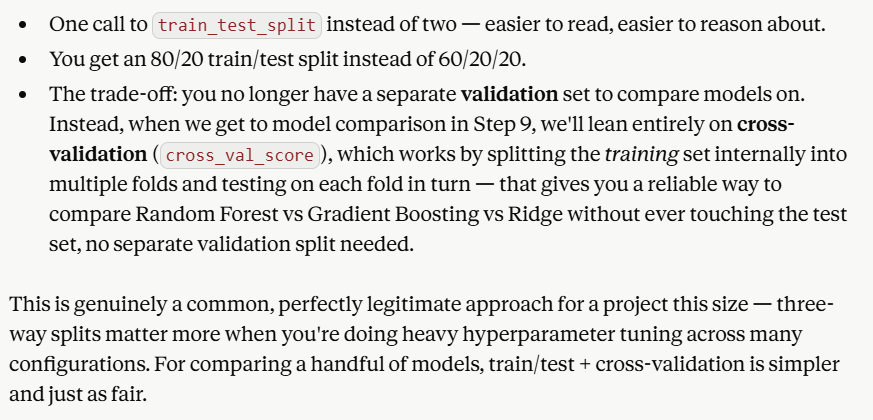

In [15]:
feature_cols = ['year', 'km_driven', 'fuel', 'seller_type', 'transmission',
                 'owner', 'car_age', 'brand', 'km_per_year']

X = data[feature_cols]
y = data['log_selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 3169
Test size: 793


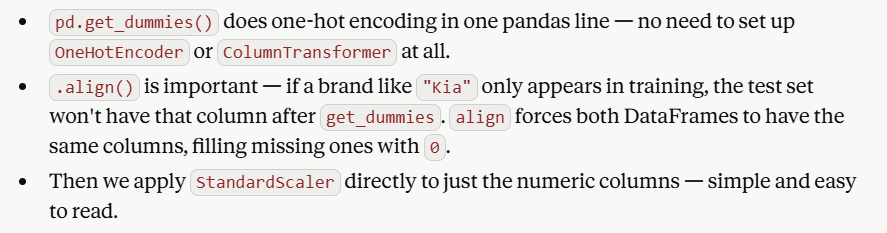

In [16]:
# Step 1: One-hot encode categorical columns directly in pandas
X_train_processed = pd.get_dummies(X_train, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'])
X_test_processed = pd.get_dummies(X_test, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'])

# Align columns — test might be missing some brand columns that train has
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='left', axis=1, fill_value=0)

# Step 2: Scale numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['year', 'km_driven', 'car_age', 'km_per_year']

X_train_processed[num_cols] = scaler.fit_transform(X_train_processed[num_cols])
X_test_processed[num_cols] = scaler.transform(X_test_processed[num_cols])

print(f"Shape before: {X_train.shape}")
print(f"Shape after:  {X_train_processed.shape}")

Shape before: (3169, 9)
Shape after:  (3169, 41)


In [17]:
X_train_processed.head()

,year,km_driven,car_age,km_per_year,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,brand_Maruti,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
1512,1.214753,-0.649435,-1.214753,0.154330,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3674,-0.221201,0.469380,0.221201,0.308878,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1259,-1.657155,0.916906,1.657155,-0.078306,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4187,0.018125,0.049824,-0.018125,0.049688,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3089,0.018125,-0.878792,-0.018125,-0.923064,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False


In [18]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

y_train_pred = lr_model.predict(X_train_processed)
y_test_pred  = lr_model.predict(X_test_processed)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)
y_train_pred_actual = np.expm1(y_train_pred)
y_test_pred_actual  = np.expm1(y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
test_rmse  = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))

print("=" * 40)
print("        LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"Train R²  : {train_r2:.4f}")
print(f"Test  R²  : {test_r2:.4f}")
print(f"Difference: {abs(train_r2 - test_r2):.4f}  ← overfitting check")
print("-" * 40)
print(f"Train RMSE: ₹{train_rmse:,.0f}")
print(f"Test  RMSE: ₹{test_rmse:,.0f}")
print("=" * 40)

        LINEAR REGRESSION RESULTS
Train R²  : 0.7382
Test  R²  : 0.7638
Difference: 0.0257  ← overfitting check
----------------------------------------
Train RMSE: ₹148,721
Test  RMSE: ₹148,778


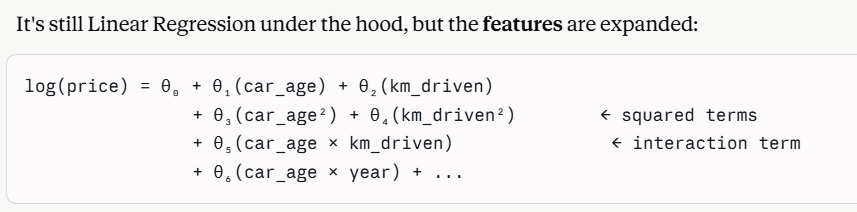

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly  = poly.transform(X_test_processed)

poly_model = Ridge(alpha=10)
poly_model.fit(X_train_poly, y_train)

y_train_pred = poly_model.predict(X_train_poly)
y_test_pred  = poly_model.predict(X_test_poly)

y_train_pred_actual = np.expm1(y_train_pred)
y_test_pred_actual  = np.expm1(y_test_pred)
y_train_actual      = np.expm1(y_train)
y_test_actual       = np.expm1(y_test)

train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
test_rmse  = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))

print("=" * 40)
print("   POLYNOMIAL REGRESSION (degree=2)")
print("=" * 40)
print(f"Train R²  : {train_r2:.4f}")
print(f"Test  R²  : {test_r2:.4f}")
print(f"Difference: {abs(train_r2 - test_r2):.4f}  ← overfitting check")
print("-" * 40)
print(f"Train RMSE: ₹{train_rmse:,.0f}")
print(f"Test  RMSE: ₹{test_rmse:,.0f}")
print("=" * 40)

   POLYNOMIAL REGRESSION (degree=2)
Train R²  : 0.7776
Test  R²  : 0.7827
Difference: 0.0051  ← overfitting check
----------------------------------------
Train RMSE: ₹134,820
Test  RMSE: ₹136,568


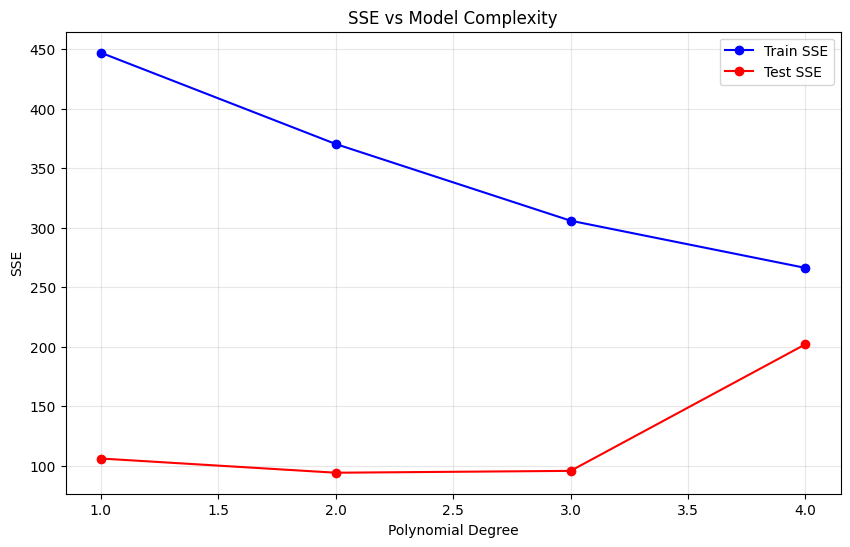

In [20]:
degrees = [1, 2, 3, 4]
train_sse_list, test_sse_list = [], []

for degree in degrees:
    poly_temp = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_temp = poly_temp.fit_transform(X_train_processed)
    X_test_temp  = poly_temp.transform(X_test_processed)

    ridge_temp = Ridge(alpha=10)
    ridge_temp.fit(X_train_temp, y_train)

    y_train_pred = ridge_temp.predict(X_train_temp)
    y_test_pred  = ridge_temp.predict(X_test_temp)

    train_sse_list.append(np.sum((y_train - y_train_pred) ** 2))
    test_sse_list.append(np.sum((y_test  - y_test_pred)  ** 2))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_sse_list, 'b-o', label='Train SSE')
plt.plot(degrees, test_sse_list,  'r-o', label='Test SSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('SSE')
plt.title('SSE vs Model Complexity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
final_poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_final = final_poly.fit_transform(X_train_processed)
X_test_final  = final_poly.transform(X_test_processed)

final_model = Ridge(alpha=10)
final_model.fit(X_train_final, y_train)

joblib.dump(final_model, 'car_price_model.pkl')
joblib.dump(final_poly,  'polynomial_features.pkl')
joblib.dump(scaler,      'scaler.pkl')
print("✅ Final model trained and saved!")

✅ Final model trained and saved!


In [25]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

# Open the response sheet — replace with your actual sheet name
SHEET_NAME = "Car dekho form (Responses)"  # change to your exact sheet name
sheet = gc.open(SHEET_NAME).sheet1

# Read all responses into a DataFrame
import pandas as pd
responses_df = pd.DataFrame(sheet.get_all_records())
print(f"Total responses so far: {len(responses_df)}")
responses_df.head()

Total responses so far: 2


,Timestamp,Email address,name,year,km_driven,Column 6,Column 7,Column 8,Column 9
0,,,,,,,,,
1,30/06/2026 09:04:35,futurefunkfam@gmail.com,Maruti,2010,2000,Petrol,Individual,Manual,First Owner


In [28]:
# Reload responses fresh
responses_df = pd.DataFrame(sheet.get_all_records())

# Rename columns by position (adjust order if your form question order differs)
responses_df.columns = [
    'Timestamp', 'Email address', 'Car Name', 'Year', 'Km Driven',
    'Fuel', 'Seller Type', 'Transmission', 'Owner'
]

# Drop empty/blank rows (e.g. test submissions with no email)
responses_df = responses_df[responses_df['Email address'].str.strip() != '']
responses_df = responses_df.reset_index(drop=True)

print(f"Valid responses: {len(responses_df)}")
responses_df

Valid responses: 1


,Timestamp,Email address,Car Name,Year,Km Driven,Fuel,Seller Type,Transmission,Owner
0,30/06/2026 09:04:35,futurefunkfam@gmail.com,Maruti,2010,2000,Petrol,Individual,Manual,First Owner


In [ ]:
import smtplib
from email.mime.text import MIMEText

# ── Your Gmail credentials (App Password, not your real password) ──
SENDER_EMAIL = "Enter your email@gmail.com"       # ← change this
APP_PASSWORD = "Enter your password"       # ← change this (16-char app password)

def predict_price(row):
    car_age = 2024 - int(row['Year'])
    brand = extract_brand(row['Car Name'])
    km_per_year = int(row['Km Driven']) / (car_age + 1)

    input_df = pd.DataFrame([{
        'year': int(row['Year']),
        'km_driven': int(row['Km Driven']),
        'fuel': row['Fuel'],
        'seller_type': row['Seller Type'],
        'transmission': row['Transmission'],
        'owner': row['Owner'],
        'car_age': car_age,
        'brand': brand,
        'km_per_year': km_per_year
    }])

    input_processed = pd.get_dummies(input_df, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'])
    input_processed = input_processed.reindex(columns=X_train_processed.columns, fill_value=0)
    input_processed[num_cols] = scaler.transform(input_processed[num_cols])
    input_poly = final_poly.transform(input_processed)

    log_price = final_model.predict(input_poly)[0]
    predicted_price = np.expm1(log_price)
    return predicted_price

def send_email(to_email, predicted_price, margin):
    low = predicted_price - margin
    high = predicted_price + margin

    subject = "Your Car Price Prediction"
    body = f"""Hello,

Thank you for using our Car Price Prediction tool!

Based on the details you provided, your car's estimated selling price is:

    ₹{predicted_price:,.0f}  (±₹{margin:,.0f})

Estimated Range: ₹{low:,.0f} - ₹{high:,.0f}

This is an automated estimate based on a machine learning model trained on historical car sales data.

Regards,
Car Price Prediction Team
"""
    msg = MIMEText(body)
    msg['Subject'] = subject
    msg['From'] = SENDER_EMAIL
    msg['To'] = to_email

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(SENDER_EMAIL, APP_PASSWORD)
        server.send_message(msg)

    print(f"✅ Email sent to {to_email}")

# ── Run for all current responses ──
margin = test_rmse  # ±RMSE from Step 9 (Linear Regression's test error)

for idx, row in responses_df.iterrows():
    price = predict_price(row)
    send_email(row['Email address'], price, margin)

✅ Email sent to futurefunkfam@gmail.com
